In [13]:
'''
如果放量上涨就跟涨，持有一段时间后卖出
'''
import pandas as pd
import numpy as np


#########################
file_name = "BTCUSDT_1h_kline.csv"

# hold_period = 8 #automobize this function, into the returning trend ratio, or shrinking in the amount of trading
rise_window = 60      #check z-score for indicating if the trend is in rising momentum, /or when short-period trend ratio gets higher than the lont-period ratio, we could say it's in rising trend
volume_window = 60*4
PER = 24 * 365

print("reading data...")
data = pd.read_csv(file_name, index_col=0)
volume_series = data["volume"]
current_time = volume_series.index[-1]

#########################

volume_series_diff = volume_series - volume_series.shift(1)
exit_signal = volume_series_diff.rolling(4).max() < 0
data['exit_signal'] = exit_signal


window = 60  
price = data['close']
rolling_mean = price.rolling(window=window).mean()
rolling_std = price.rolling(window=window).std()
zscore = (price - rolling_mean) / rolling_std

data['signal'] = zscore.clip(lower=0)


def rolling_rank(series):
    """返回窗口中最后一个值在该窗口内的百分比排名"""
    return series.rank(pct=True).iloc[-1]

def momentum_detect(data, trend_window=60, volume_window=60*4, z_thresh=1.0, vol_thresh=3.0):
    # z-score instead of rise_up
    rolling_mean = data['close'].rolling(window=trend_window, min_periods=1).mean()
    rolling_std = data['close'].rolling(window=trend_window, min_periods=1).std()
    zscore = (data['close'] - rolling_mean) / (rolling_std + 1e-9)
    trend_score = zscore.clip(lower=0)
    trend_up = trend_score.apply(lambda x: 1 if x > z_thresh else 0)

    mean_volume = data['volume'].rolling(window=volume_window, min_periods=1).mean()
    std_volume = data['volume'].rolling(window=volume_window, min_periods=1).std()
    volume_zscore = (data['volume'] - mean_volume) / (std_volume + 1e-9)
    volume_up = volume_zscore.apply(lambda x: 1 if x > vol_thresh else 0)

    signal = trend_up * volume_up
    return signal

data['signal'] = momentum_detect(data, trend_window=60, volume_window=240, z_thresh=1.0, vol_thresh=3.0)
data['signal'] = data['signal'].shift(1)

print("\n基准收益")
ret = np.log(data['close'] / data['open'])
print(f"年化收益: {ret.mean() * PER*100:.2f}%")
print(f"夏普比率: {ret.mean() / ret.std() * np.sqrt(PER):.2f}")  #1.5

target_position = pd.Series(0, index=data.index)

in_position = False

for t in range(1, len(data)):
    if not in_position:
        if data['signal'].iloc[t-1] == 1:
            in_position = True
            target_position.iloc[t] = 1
    else:
        if data['exit_signal'].iloc[t]:
            in_position = False
            target_position.iloc[t] = 0
        else:
            target_position.iloc[t] = 1 


ret = target_position * np.log(data['close'] / data['open'])
data['ret'] = ret
annual_retrun = ret.mean() * PER
print(f"\n年化收益: {annual_retrun*100:.2f}%")
sharpe_ratio = ret.mean() / ret.std() * np.sqrt(PER)
print(f"夏普比率: {sharpe_ratio:.2f}")      #1.8
data.to_csv("BTCUSDT_1m_kline_signal.csv")

reading data...

基准收益
年化收益: 50.22%
夏普比率: 0.78

年化收益: 24.18%
夏普比率: 1.05


<Axes: xlabel='open_time'>

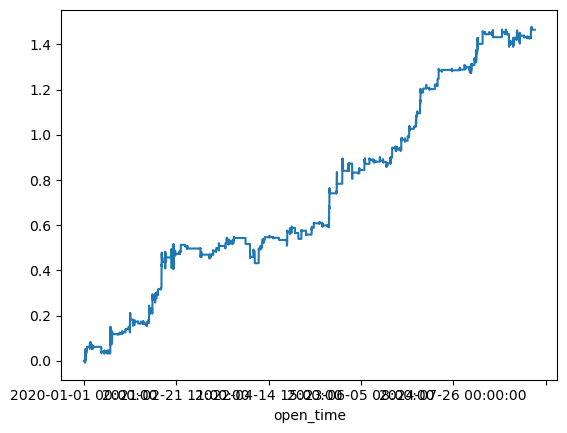

In [2]:
ret.cumsum().plot()

<Axes: xlabel='open_time'>

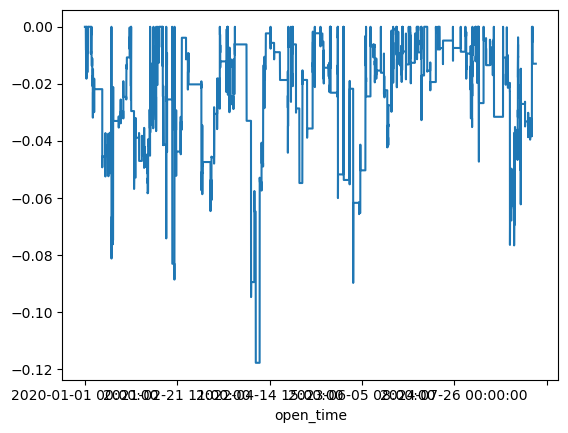

In [5]:
(ret.cumsum() - ret.cumsum().cummax()).plot()